In [1]:
%autosave 60
%pip install --quiet -r requirements.txt

Autosaving every 60 seconds
Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import os
import numpy as np
import random
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict
from models.MiniEncoder3D import MiniEncoder3D, PhiFeatureExtractor
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import fit_3D, fit_3D_gan
from utils.loss_functions import recon_loss, ssim_L1_2d_loss
from models.alzheiminator_3d import ResidualUNet3D, Discriminator3D, Generator3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Flush cuda memory

In [3]:
torch.cuda.empty_cache()

Common Variables

In [4]:
model_epochs = 101
print_every = 25
save_every = 50

In [5]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


## 3D U-Net

In [6]:
output_dir = "out/unet_models"
unet_path = f"{output_dir}/3d_unet_model.pt"
unet = ResidualUNet3D(in_ch=1, base=32).to(device)
unet_optimizer = optim.AdamW(unet.parameters(), lr=1e-4, weight_decay=1e-5)

In [7]:
# Load existing model if it exists
if os.path.isfile(unet_path):
    print("Loading existing model")
    unet.load_state_dict(torch.load(unet_path))
else:
    print("No existing 3D U-Net found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing 3D U-Net found, starting fresh training.
562 training pairs


In [8]:
unet, unet_snapshots = fit_3D(
    model=unet,
    optimizer=unet_optimizer,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    criterion=recon_loss,
    epochs=model_epochs,
    print_every=print_every,
    save_every=save_every
)

[Iter 0] total: 0.460947 (custom criterion) + TV
Saved snapshot at iter 0 (mid-axial slice)
[Iter 25] total: 0.248607 (custom criterion) + TV
[Iter 50] total: 0.103777 (custom criterion) + TV
Saved snapshot at iter 50 (mid-axial slice)
[Iter 75] total: 0.088775 (custom criterion) + TV
[Iter 100] total: 0.074679 (custom criterion) + TV
Saved snapshot at iter 100 (mid-axial slice)


Displaying snapshot from pair 0, loss: 0.4609


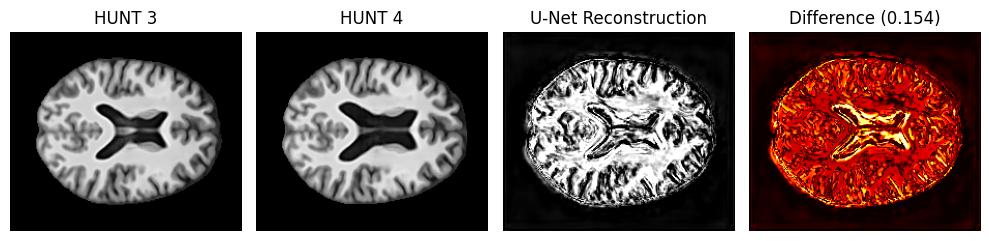

Displaying snapshot from pair 50, loss: 0.1038


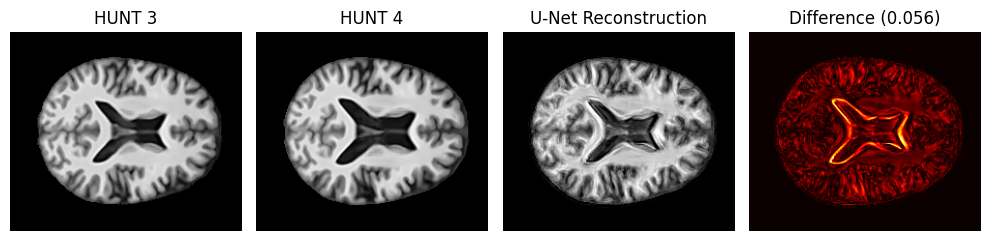

Displaying snapshot from pair 100, loss: 0.0747


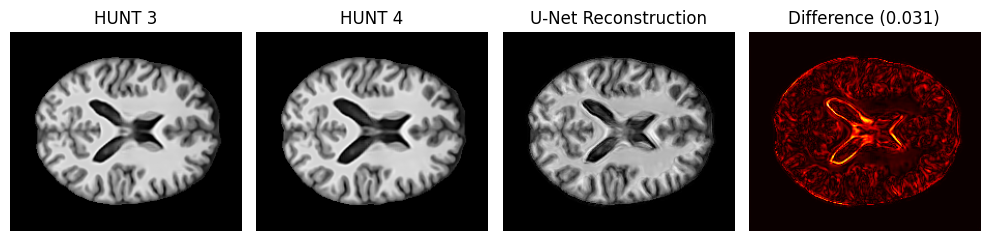

In [9]:
for snapshot in unet_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}, loss: {snapshot['loss']:.4f}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "U-Net Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [10]:
# Save the final model to the /out directory
torch.save(unet.state_dict(), unet_path)
print(f"Model saved to {unet_path}")

Model saved to out/unet_models/3d_unet_model.pt


## MP-GAN

In [11]:
output_dir = "out/gan_models"
generator_path = f"{output_dir}/3d_mpgan_model_G.pt"
discriminator_path = f"{output_dir}/3d_mpgan_model_D.pt"

generator = Generator3D(in_channels=1, out_channels=1).to(device)
discriminator = Discriminator3D(in_channels=1).to(device)
generator_optimizer = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))
base_enc = MiniEncoder3D(in_ch=1, chs=(16,32,64,128))   # Can swap with pretrained encoder
phi = PhiFeatureExtractor(base_enc).to(device)

In [12]:
# Load existing model if it exists
if os.path.isfile(generator_path) and os.path.isfile(discriminator_path):
    print("Loading existing GAN models")
    generator.load_state_dict(torch.load(generator_path)) 
    discriminator.load_state_dict(torch.load(discriminator_path))
else:
    print("No existing GAN models found, starting fresh training.")
    os.makedirs(output_dir, exist_ok=True)
    
print(len(training_pairs), "training pairs")

No existing GAN models found, starting fresh training.
562 training pairs


In [13]:
# Use with fit_3D
generator, discriminator, gan_snapshots = fit_3D_gan(
    G=generator,
    D=discriminator,
    device=device,
    dataLoader=data_loader,
    training_pairs=training_pairs,
    epochs=model_epochs,
    lr_G=1e-4,
    lr_D=1e-4,
    opt_G=generator_optimizer,
    opt_D=discriminator_optimizer, 
    trim_slices=0,
    crop_size=(193,229),
    phi=phi,
    print_every=print_every,
    save_every=save_every
)

[Iter 0] D_total=0.6994 G_total=38.7367 L1=0.3538 Perc=1.1649 AdvG=0.7682
Saved snapshot at iter 0
[Iter 25] D_total=0.4681 G_total=27.5825 L1=0.3086 Perc=0.7516 AdvG=1.0775
[Iter 50] D_total=0.4070 G_total=26.8278 L1=0.2949 Perc=0.7314 AdvG=1.1689
Saved snapshot at iter 50
[Iter 75] D_total=0.3660 G_total=25.3056 L1=0.2844 Perc=0.6774 AdvG=1.2619
[Iter 100] D_total=0.3355 G_total=25.9326 L1=0.2768 Perc=0.7067 AdvG=1.3452
Saved snapshot at iter 100


Displaying snapshot from pair 0


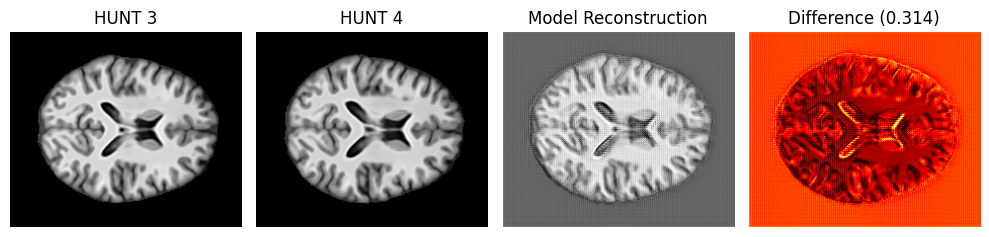

Displaying snapshot from pair 50


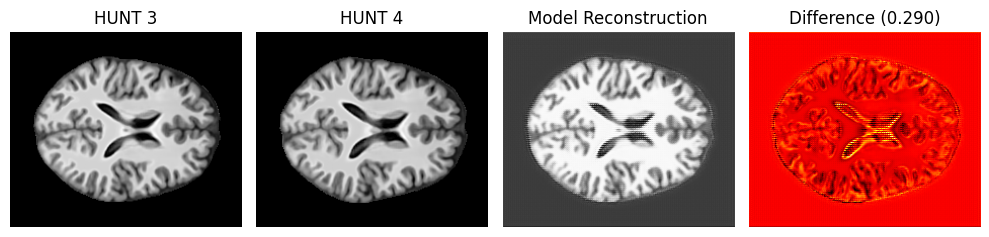

Displaying snapshot from pair 100


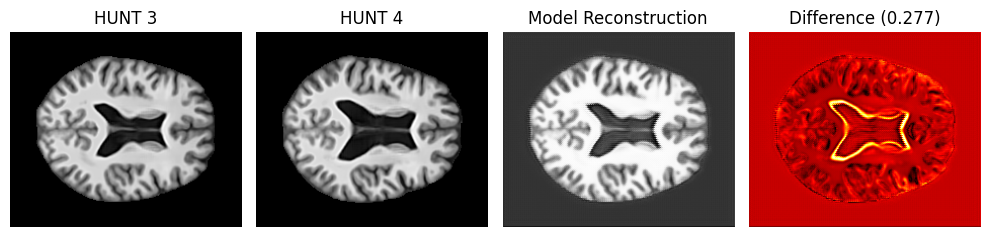

In [14]:
for snapshot in gan_snapshots:
    print(f"Displaying snapshot from pair {snapshot['iter']}")
    difference = np.abs(snapshot["recon"] - snapshot["y"])
    data_loader.display_slices([snapshot["x"], snapshot["y"], snapshot["recon"], difference], slice_labels=["HUNT 3", "HUNT 4", "Model Reconstruction", f"Difference ({np.mean(difference):.3f})"], slice_colors=["gray", "gray", "gray", "hot"])

In [15]:
# Save the final model to /out directory
torch.save(generator.state_dict(), generator_path)
torch.save(discriminator.state_dict(), discriminator_path)
print(f"Generator saved to {generator_path}")
print(f"Discriminator saved to {discriminator_path}")

Generator saved to out/gan_models/3d_mpgan_model_G.pt
Discriminator saved to out/gan_models/3d_mpgan_model_D.pt


## Display evenly spaced results from both models

In [16]:
test_images = 4

# Same split as during training
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


In [17]:
for i in range(test_images):
    padding = 15
    slice = int(padding + i * ((192 - 2 * padding) / test_images))
    candidate = random.randint(0, len(test_pairs)-1)

    # Generate 3D predictions
    x_num, y_num = data_loader.load_from_path(path=test_pairs[candidate][0], crop_size=(64, 192, 224)), data_loader.load_from_path(path=test_pairs[candidate][1], crop_size=(64, 192, 224))
    x = torch.from_numpy(x_num).float()[None, None].to(device)
    y = torch.from_numpy(y_num).float()[None, None].to(device)
    unet_recon_tensor = unet(x)
    mpgan_recon_tensor = generator(x)

    # Convert Tensor reconstructions to numpy for display
    recon_unet = unet_recon_tensor.detach().cpu().squeeze().clamp(0,1).numpy()
    recon_mpgan = mpgan_recon_tensor.detach().cpu().squeeze().clamp(0,1).numpy()

    # How much the models change from the input
    change_unet = np.abs(recon_unet - x_num[slice])
    change_mpgan = np.abs(recon_mpgan - x_num[slice])

    # Difference between reconstructions and ground truth
    diff_unet = np.abs(recon_unet - y_num[slice])
    diff_mpgan = np.abs(recon_mpgan - y_num[slice])
    hunt_diff = np.abs(x_num[slice] - y_num[slice])

    # Prediction errors
    pred_error_unet = ssim_L1_2d_loss(unet_recon_tensor, y).item()
    pred_error_mpgan = ssim_L1_2d_loss(mpgan_recon_tensor, y).item()
    print(f"Displaying results for test image {candidate}, slice {slice}")

    # Hunt 3, Hunt 4, and the difference between them
    data_loader.display_slices(
        slices=[x_num[slice], y_num[slice], hunt_diff],
        slice_labels=["HUNT 3", "HUNT 4", "HUNT 3 vs HUNT 4 Diff"],
        slice_colors=["gray", "gray", "hot"]
    )

    # The two models’ outputs
    data_loader.display_slices(
        slices=[recon_unet, recon_mpgan],
        slice_labels=["Unet Recon", "MPGAN Recon"],
        slice_colors=["gray", "gray"]
    )

    # The two models’ change from HUNT 3
    data_loader.display_slices(
        slices=[change_unet, change_mpgan],
        slice_labels=["Unet Change", "MPGAN Change"],
        slice_colors=["hot", "hot"]
    )

    # The two models’ difference from HUNT 4
    data_loader.display_slices(
        slices=[diff_unet, diff_mpgan],
        slice_labels=[
            f"Slice Loss ({pred_error_unet:.3f})",
            f"Slice loss ({pred_error_mpgan:.3f})",
        ],
        slice_colors=["hot", "hot"]
    )

AttributeError: 'tuple' object has no attribute 'detach'